<a href="https://colab.research.google.com/github/Gaurav-Rawool/Machin-learning/blob/main/Gaurav_ML__Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

 Name - Gaurav Rawool , CE_39

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [8]:
# =========================
# TASK 1: ENVIRONMENT SETUP AND DATASET UPLOAD
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# Upload CSV file
from google.colab import files

uploaded = files.upload()

# Get the uploaded filename
file_name = next(iter(uploaded))

# Load the dataset
df = pd.read_csv(file_name)

# Assign column headers
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df.columns = columns

# Print first five records
print("First five records:")
print(df.head())

# Print dataset shape
print("\nDataset shape:")
print(df.shape)

# Print data types
print("\nData types of all features:")
print(df.dtypes)

# Print descriptive statistics
print("\nDescriptive statistics:")
print(df.describe())

Saving diabetes (2).csv to diabetes (2).csv
First five records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)

Data types of all features:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI  

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Distribution:
--------------------------------
Non-Diabetic (Outcome = 0): 500 cases (65.10%)
Diabetic (Outcome = 1):     268 cases (34.90%)


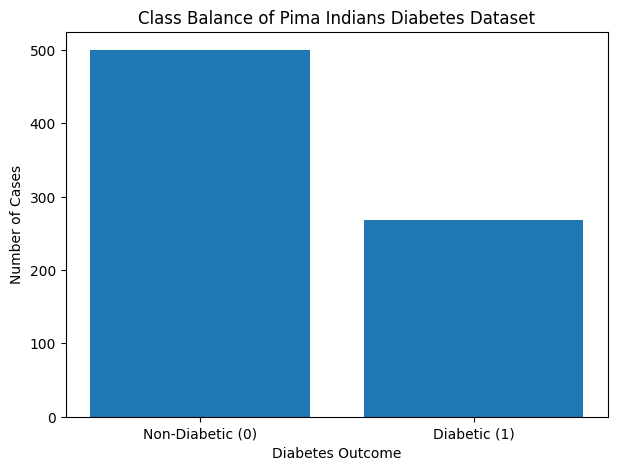

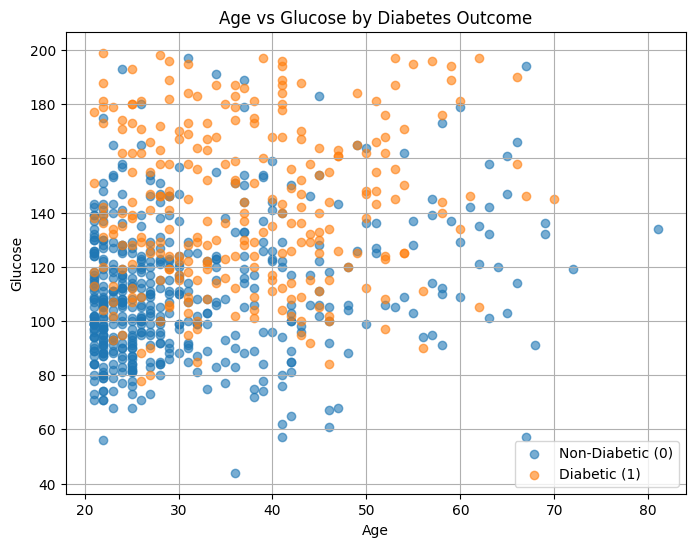


Explanation:
A simple linear decision boundary is insufficient because diabetic and non-diabetic cases overlap in the Age-Glucose space. Diabetes is influenced by multiple features such as Glucose, BMI, Age, Insulin, BloodPressure, and DiabetesPedigreeFunction. Therefore, a single straight-line boundary cannot clearly separate the two classes.


In [9]:
# =========================
# TASK 2: EXPLORATORY DATA ANALYSIS
# =========================

# 1. Calculate absolute count and percentage of each class

class_counts = df["Outcome"].value_counts().sort_index()
class_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Class Distribution:")
print("--------------------------------")

print(f"Non-Diabetic (Outcome = 0): {class_counts[0]} cases "
      f"({class_percentages[0]:.2f}%)")

print(f"Diabetic (Outcome = 1):     {class_counts[1]} cases "
      f"({class_percentages[1]:.2f}%)")


# Plot class balance using a bar chart

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    [class_counts[0], class_counts[1]]
)

plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Cases")
plt.title("Class Balance of Pima Indians Diabetes Dataset")

plt.show()


# 2. Scatter plot of Age against Glucose
# Color-coded according to Outcome

plt.figure(figsize=(8, 6))

# Non-diabetic cases
plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.6
)

# Diabetic cases
plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    label="Diabetic (1)",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose by Diabetes Outcome")
plt.legend()
plt.grid(True)

plt.show()


# 3. Explanation

print("\nExplanation:")
print(
    "A simple linear decision boundary is insufficient because "
    "diabetic and non-diabetic cases overlap in the Age-Glucose space. "
    "Diabetes is influenced by multiple features such as Glucose, BMI, "
    "Age, Insulin, BloodPressure, and DiabetesPedigreeFunction. "
    "Therefore, a single straight-line boundary cannot clearly separate "
    "the two classes."
)

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [10]:
# =========================
# TASK 3: PREPROCESSING AND HANDLING MISSING VALUES
# =========================

# Features where a value of 0 is physically impossible
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Create a copy of the dataset
df_processed = df.copy()

# Step 1: Count invalid zero values before replacement
print("Invalid zero values before replacement:")
print("---------------------------------------")

for column in invalid_features:
    zero_count = (df_processed[column] == 0).sum()
    print(f"{column}: {zero_count}")


# Step 2: Replace invalid 0 values with NaN

df_processed[invalid_features] = (
    df_processed[invalid_features].replace(0, np.nan)
)


# Display missing values after replacement
print("\nMissing values after replacing 0 with NaN:")
print("--------------------------------------------")
print(df_processed.isnull().sum())


# Step 3: Impute missing values using the median

for column in invalid_features:
    median_value = df_processed[column].median()
    df_processed[column] = df_processed[column].fillna(median_value)


# Step 4: Verify that no missing values remain

print("\nMissing values after median imputation:")
print("---------------------------------------")
print(df_processed.isnull().sum())


# Total missing values
print("\nTotal missing values:")
print(df_processed.isnull().sum().sum())


# Display first five records after preprocessing
print("\nFirst five records after preprocessing:")
print(df_processed.head())

Invalid zero values before replacement:
---------------------------------------
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0

Missing values after replacing 0 with NaN:
--------------------------------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
---------------------------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values:
0

First five records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [11]:
# =========================
# TASK 4: STRATIFIED TRAIN-TEST SPLITTING
# =========================

from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)

# First 8 columns are features
X = df_processed.iloc[:, :8].values

# 9th column is the target
y = df_processed.iloc[:, 8].values

# Display shapes before splitting
print("Original feature shape:", X.shape)
print("Original target shape:", y.shape)


# 2. Split the dataset into 80% training and 20% testing
# stratify=y preserves the class proportions

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Display training and testing shapes

print("\nTraining feature shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("Testing feature shape:", X_test.shape)
print("Testing target shape:", y_test.shape)


# 3. Check class distribution in training data

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTraining class percentages:")
print(
    (pd.Series(y_train).value_counts(normalize=True).sort_index() * 100)
)


# 4. Check class distribution in testing data

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nTesting class percentages:")
print(
    (pd.Series(y_test).value_counts(normalize=True).sort_index() * 100)
)

Original feature shape: (768, 8)
Original target shape: (768,)

Training feature shape: (614, 8)
Training target shape: (614,)
Testing feature shape: (154, 8)
Testing target shape: (154,)

Training class distribution:
0    400
1    214
Name: count, dtype: int64

Training class percentages:
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Testing class distribution:
0    100
1     54
Name: count, dtype: int64

Testing class percentages:
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [12]:
# =========================
# TASK 5: CUSTOM BOOTSTRAP SAMPLING
# =========================

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample using sampling with replacement.
    """

    # Number of training samples
    N = X.shape[0]

    # Randomly select N indices with replacement
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap feature matrix and target vector
    X_bootstrap = X[sample_indices]
    y_bootstrap = y[sample_indices]

    return X_bootstrap, y_bootstrap, sample_indices


# Set random seed for reproducibility
np.random.seed(42)

# Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# =========================
# VERIFY BOOTSTRAP SAMPLE
# =========================

print("Original training size:", len(X_train))
print("Bootstrap sample size:", len(X_bootstrap))


# Find duplicated indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nNumber of unique sampled indices:", len(unique_indices))
print("Number of duplicated indices:", len(duplicated_indices))

if len(duplicated_indices) > 0:
    print("Example duplicated indices:", duplicated_indices[:10])


# Find Out-of-Bag (OOB) indices
all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nNumber of OOB samples:", len(oob_indices))
print("Example OOB indices:", oob_indices[:10])


# Final verification
print("\nBootstrap sampling verification:")
print("Duplicates present:", len(duplicated_indices) > 0)
print("OOB samples present:", len(oob_indices) > 0)

Original training size: 614
Bootstrap sample size: 614

Number of unique sampled indices: 377
Number of duplicated indices: 164
Example duplicated indices: [ 1  4  8 11 14 20 21 27 32 34]

Number of OOB samples: 237
Example OOB indices: [ 2  3  5  6 10 12 23 25 29 30]

Bootstrap sampling verification:
Duplicates present: True
OOB samples present: True


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [13]:
# =========================
# TASK 6: GROWING THE ENSEMBLE
# =========================

from sklearn.tree import DecisionTreeClassifier

# Number of bootstrap iterations / decision trees
B = 50

# Empty list to store trained models
ensemble = []

# Set random seed for reproducibility
np.random.seed(42)

# Train 50 decision trees
for b in range(B):

    # Generate a bootstrap sample
    X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the decision tree
    model.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add the trained model to the ensemble
    ensemble.append(model)


# =========================
# VERIFY THE ENSEMBLE
# =========================

print("Number of trees in ensemble:", len(ensemble))
print("Expected number of trees:", B)

print("\nAll trees trained successfully.")

# Check the type of the first model
print("\nType of first model:")
print(type(ensemble[0]))

Number of trees in ensemble: 50
Expected number of trees: 50

All trees trained successfully.

Type of first model:
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [14]:
# =========================
# TASK 7: CUSTOM BAGGING PREDICTION
# =========================

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting
    from all decision trees in the ensemble.
    """

    # Store predictions from every decision tree
    all_predictions = np.array([
        model.predict(X_test)
        for model in ensemble
    ])

    # List to store final majority-voted predictions
    final_predictions = []

    # Perform majority voting for each test sample
    for i in range(X_test.shape[0]):

        # Count votes for class 0
        votes_class_0 = np.sum(
            all_predictions[:, i] == 0
        )

        # Count votes for class 1
        votes_class_1 = np.sum(
            all_predictions[:, i] == 1
        )

        # Select the class with the highest number of votes
        if votes_class_1 > votes_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Convert predictions to NumPy array
    return np.array(final_predictions)


# =========================
# GENERATE BAGGING PREDICTIONS
# =========================

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# =========================
# DISPLAY RESULTS
# =========================

print("First 20 Bagging predictions:")
print(y_pred_bagging[:20])

print("\nNumber of test predictions:")
print(len(y_pred_bagging))

print("\nUnique predicted classes:")
print(np.unique(y_pred_bagging))

print("\nPrediction shape:")
print(y_pred_bagging.shape)

First 20 Bagging predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]

Number of test predictions:
154

Unique predicted classes:
[0 1]

Prediction shape:
(154,)


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [15]:
# =========================
# TASK 8: SINGLE TREE VS BAGGING
# =========================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------
# 1. Train a single fully grown tree
# ---------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)


# ---------------------------------
# 2. Make predictions
# ---------------------------------

# Single decision tree predictions
y_pred_single = single_tree.predict(X_test)

# Custom Bagging predictions
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ---------------------------------
# 3. Confusion Matrices
# ---------------------------------

cm_single = confusion_matrix(
    y_test,
    y_pred_single
)

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)


print("======================================")
print("CONFUSION MATRICES")
print("======================================")

print("\nSingle Decision Tree:")
print(cm_single)

print("\nCustom Bagging:")
print(cm_bagging)


# ---------------------------------
# 4. Calculate performance metrics
# ---------------------------------

# Single Decision Tree
accuracy_single = accuracy_score(y_test, y_pred_single)
precision_single = precision_score(
    y_test, y_pred_single, zero_division=0
)
recall_single = recall_score(
    y_test, y_pred_single, zero_division=0
)
f1_single = f1_score(
    y_test, y_pred_single, zero_division=0
)


# Custom Bagging
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(
    y_test, y_pred_bagging, zero_division=0
)
recall_bagging = recall_score(
    y_test, y_pred_bagging, zero_division=0
)
f1_bagging = f1_score(
    y_test, y_pred_bagging, zero_division=0
)


# ---------------------------------
# 5. Print performance results
# ---------------------------------

print("\n======================================")
print("PERFORMANCE RESULTS")
print("======================================")

print("\nSingle Decision Tree:")
print(f"Accuracy : {accuracy_single:.4f}")
print(f"Precision: {precision_single:.4f}")
print(f"Recall   : {recall_single:.4f}")
print(f"F1-Score : {f1_single:.4f}")


print("\nCustom Bagging:")
print(f"Accuracy : {accuracy_bagging:.4f}")
print(f"Precision: {precision_bagging:.4f}")
print(f"Recall   : {recall_bagging:.4f}")
print(f"F1-Score : {f1_bagging:.4f}")


# ---------------------------------
# 6. Create comparison table
# ---------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Single Decision Tree": [
        accuracy_single,
        precision_single,
        recall_single,
        f1_single
    ],
    "Custom Bagging": [
        accuracy_bagging,
        precision_bagging,
        recall_bagging,
        f1_bagging
    ]
})

print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

print(comparison.to_string(index=False))

CONFUSION MATRICES

Single Decision Tree:
[[87 13]
 [16 38]]

Custom Bagging:
[[90 10]
 [11 43]]

PERFORMANCE RESULTS

Single Decision Tree:
Accuracy : 0.8117
Precision: 0.7451
Recall   : 0.7037
F1-Score : 0.7238

Custom Bagging:
Accuracy : 0.8636
Precision: 0.8113
Recall   : 0.7963
F1-Score : 0.8037

MODEL COMPARISON
   Metric  Single Decision Tree  Custom Bagging
 Accuracy              0.811688        0.863636
Precision              0.745098        0.811321
   Recall              0.703704        0.796296
 F1-Score              0.723810        0.803738


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

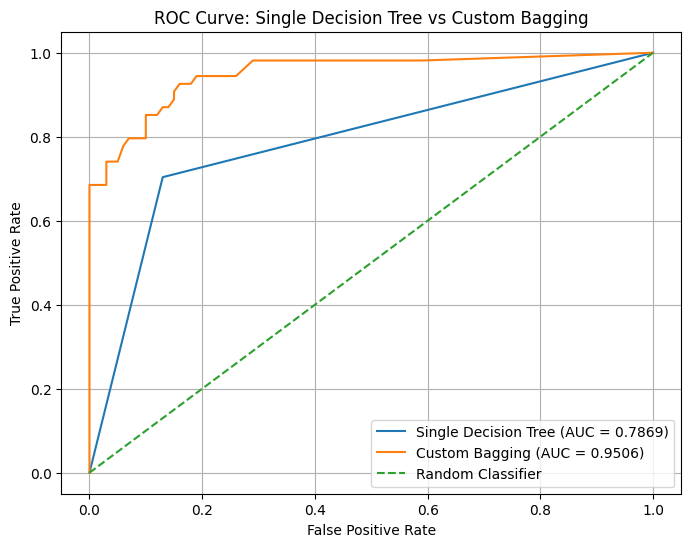

ROC-AUC RESULTS
Single Decision Tree AUC: 0.7869
Custom Bagging AUC:      0.9506

AUC Comparison:
Custom Bagging has a higher AUC than the Single Decision Tree.


In [16]:
# =========================
# TASK 9: ROC-AUC ANALYSIS
# =========================

from sklearn.metrics import roc_curve, roc_auc_score

# ---------------------------------
# 1. Single Decision Tree probabilities
# ---------------------------------

# Get probability of class 1 (Diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# ---------------------------------
# 2. Custom Bagging probabilities
# ---------------------------------

# Get probability of class 1 from every tree
all_tree_probabilities = np.array([
    model.predict_proba(X_test)[:, 1]
    for model in ensemble
])

# Average probabilities across all 50 trees
y_prob_bagging = np.mean(
    all_tree_probabilities,
    axis=0
)


# ---------------------------------
# 3. Calculate ROC curves
# ---------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# ---------------------------------
# 4. Calculate AUC
# ---------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# ---------------------------------
# 5. Plot ROC curves
# ---------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.4f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")
plt.legend()
plt.grid(True)

plt.show()


# ---------------------------------
# 6. Print AUC results
# ---------------------------------

print("======================================")
print("ROC-AUC RESULTS")
print("======================================")

print(f"Single Decision Tree AUC: {auc_single:.4f}")
print(f"Custom Bagging AUC:      {auc_bagging:.4f}")

# Compare AUC values
print("\nAUC Comparison:")

if auc_bagging > auc_single:
    print("Custom Bagging has a higher AUC than the Single Decision Tree.")
elif auc_bagging < auc_single:
    print("Single Decision Tree has a higher AUC than Custom Bagging.")
else:
    print("Both models have the same AUC.")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [17]:
# =========================
# TASK 10: VALIDATION AGAINST SCIKIT-LEARN BAGGING
# =========================

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Create Scikit-Learn BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Predict on test data
y_pred_sklearn = bagging_model.predict(X_test)

# Calculate accuracy
accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)

# Calculate confusion matrix
cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

# Display results
print("======================================")
print("SCIKIT-LEARN BAGGING CLASSIFIER")
print("======================================")

print("\nNumber of Trees:", 50)

print("\nTest Accuracy:")
print(f"{accuracy_sklearn:.4f}")

print("\nConfusion Matrix:")
print(cm_sklearn)


# =========================
# COMPARE WITH CUSTOM BAGGING
# =========================

accuracy_custom = accuracy_score(
    y_test,
    y_pred_bagging
)

cm_custom = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("\n======================================")
print("CUSTOM BAGGING VS SCIKIT-LEARN")
print("======================================")

print("\nCustom Bagging Accuracy:")
print(f"{accuracy_custom:.4f}")

print("\nScikit-Learn Bagging Accuracy:")
print(f"{accuracy_sklearn:.4f}")

print("\nCustom Bagging Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)


# Calculate accuracy difference
difference = abs(
    accuracy_custom - accuracy_sklearn
)

print("\nAccuracy Difference:")
print(f"{difference:.4f}")

SCIKIT-LEARN BAGGING CLASSIFIER

Number of Trees: 50

Test Accuracy:
0.8831

Confusion Matrix:
[[91  9]
 [ 9 45]]

CUSTOM BAGGING VS SCIKIT-LEARN

Custom Bagging Accuracy:
0.8636

Scikit-Learn Bagging Accuracy:
0.8831

Custom Bagging Confusion Matrix:
[[90 10]
 [11 43]]

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Accuracy Difference:
0.0195


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?